In [1]:
# Import required libraries
# Pandas and NumPy - Data processing
# Sklearn - Machine Learning model creation
# Matplotlib and Seaborn - Visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import pickle

In [2]:
# Load dataset

df = pd.read_csv(
    r"C:\Users\somes\OneDrive\Pictures\Attachments\Desktop\Documents\apex planet\task-4\SuperMarket Analysis.csv"
)

# Display first records

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
# Check dataset information

df.info()


# Statistical summary

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [4]:
# Check missing values

df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [5]:
# Selecting required columns

data = df[
[
"Branch",
"City",
"Customer type",
"Gender",
"Product line",
"Unit price",
"Quantity",
"Payment",
"Rating",
"Sales"
]
]

data.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,Ewallet,9.1,548.9715
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,Cash,9.6,80.2200
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,Credit card,7.4,340.5255
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,Ewallet,8.4,489.0480
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,Ewallet,5.3,634.3785


In [6]:
# Convert categorical values into numeric values

encoder = LabelEncoder()

columns = [
"Branch",
"City",
"Customer type",
"Gender",
"Product line",
"Payment"
]


for col in columns:
    data[col] = encoder.fit_transform(data[col])


data.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Sales
0,0,2,0,0,3,74.69,7,2,9.1,548.9715
1,2,1,1,0,0,15.28,5,0,9.6,80.2200
2,0,2,1,0,4,46.33,7,1,7.4,340.5255
3,0,2,0,0,3,58.22,8,2,8.4,489.0480
4,0,2,0,0,5,86.31,7,2,5.3,634.3785


In [7]:
# Separate input and output

X = data.drop("Sales", axis=1)

y = data["Sales"]


# Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Create Linear Regression model

model = LinearRegression()


# Train the model

model.fit(X_train, y_train)


print("Model Training Completed")

Model Training Completed


In [9]:
# Predict sales

y_pred = model.predict(X_test)


y_pred[:10]

array([515.05325066, 597.48156799, 407.32696679,  97.89995973,
       -85.6133618 , 600.85877465, 140.84964086, 660.70287313,
       485.33629777, 124.25686948])

In [10]:
# Evaluate model performance

print("MAE:", mean_absolute_error(y_test,y_pred))

print("MSE:", mean_squared_error(y_test,y_pred))

print("R2 Score:", r2_score(y_test,y_pred))

MAE: 59.066630458650906
MSE: 6326.450123376895
R2 Score: 0.9027582731531927


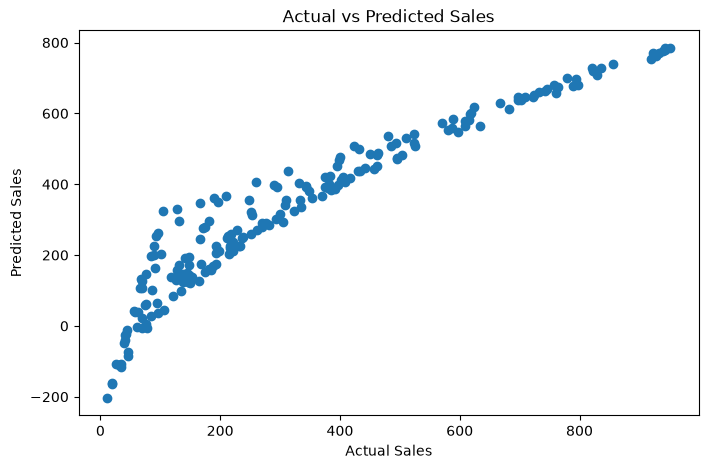

In [11]:
# Visualization of actual vs predicted sales

plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [12]:
# Save trained machine learning model

with open("sales_prediction_model.pkl","wb") as file:
    pickle.dump(model,file)


print("Model Saved Successfully")

Model Saved Successfully
